<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/check4m.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np

# Define parameters
m = 2
p = 0
N = 4 * m
theta = 2 * p - 1

print(f"Parameters: m = {m}, p = {p}, N = {N}, theta = {theta}")

# Calculate w and G_theta
w = np.exp((-2 * np.pi * 1j) / N)
G_theta = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        exponent = (k - theta/2) * (l - theta/2)
        G_theta[k, l] = (1/np.sqrt(N)) * (w ** exponent)

# Identity matrix
I = np.eye(N)

# Calculate G_theta squared
G_squared = np.dot(G_theta, G_theta)

# Calculate P_theta and Q_theta
P_theta = 0.5 * (I - G_squared)
Q_theta = 0.5 * (I + G_squared)

# Extract real parts
P_theta_real = np.real(P_theta)
Q_theta_real = np.real(Q_theta)

# Calculate S and C
S = np.imag(G_theta)
C = np.real(G_theta)

# Construct Phi matrix with safe indexing
components = []

if p  > 0:
    q_first = Q_theta_real[:p, :]
    components.append(q_first)

if 2*m - p > 0:
    q_last = Q_theta_real[-(2*m-p):, :]
    components.append(q_last)

if p > 0:
    p_first = P_theta_real[:p, :]
    components.append(p_first)

if 2*m - p > 0:
    p_last = P_theta_real[-(2*m-p):, :]
    components.append(p_last)

# Combine all rows to form Phi
if components:
    Phi = np.vstack(components)

    # Use pseudo-inverse instead of regular inverse for stability
    Phi_inv = np.linalg.pinv(Phi)

    # Calculate the transformation: Phi @ S @ Phi_inv
    result = Phi @ S @ Phi_inv

    print(f"\nPhi shape: {Phi.shape}")
    print(f"Result shape: {result.shape}")

    print(f"\nresult")
    print(np.round(result,6))

    # Extract the B block
    if result.shape[0] >= 2*m:
        B = result[2*m:, 2*m:]
        print(f"\nB matrix (shape: {B.shape}):")
        print(np.array_str(B, precision=6, suppress_small=True))

        print(f"\nBsquare:")
        print(np.array_str(B@B, precision=6, suppress_small=True))

        # Check if B @ (B - I) + (B - I) = 0
        I_B = np.eye(B.shape[0])
        left_side = B @ (B - I_B) + (B - I_B)

        if np.allclose(left_side, np.zeros(B.shape), atol=1e-10):
            print("B @ (B - I) + (B - I) = 0 is TRUE")
        else:
            print("B @ (B - I) + (B - I) = 0 is FALSE")

        # Check if B @ (B + I) - (B + I) = 0
        left_side2 = B @ (B + I_B) - (B + I_B)

        if np.allclose(left_side2, np.zeros(B.shape), atol=1e-10):
            print("B @ (B + I) - (B + I) = 0 is TRUE")
        else:
            print("B @ (B + I) - (B + I) = 0 is FALSE")

        # Create Vp and Vm matrices
        B_size = B.shape[0]
        Vp = np.zeros((N, N))
        Vm = np.zeros((N, N))

        # Place B + I and B - I in the bottom-left corner
        Vp[N-B_size:, :B_size] = B + I_B
        Vm[N-B_size:, :B_size] = B - I_B

        # Calculate W3 and W4
        W3 = Phi_inv @ Vm
        W4 = Phi_inv @ Vp

        print(f"\nW3 shape: {W3.shape}")
        print(f"W4 shape: {W4.shape}")

        # Check G_theta @ W3 + 1j* W3 = 0
        left_side_w3 = G_theta @ W3 + 1j * W3
        if np.allclose(left_side_w3, np.zeros(W3.shape), atol=1e-10):
            print("G_theta @ W3 + 1j* W3 = 0 is TRUE")
        else:
            print("G_theta @ W3 + 1j* W3 = 0 is FALSE")

        # Check G_theta @ W4 - 1j* W4 = 0
        left_side_w4 = G_theta @ W4 - 1j * W4
        if np.allclose(left_side_w4, np.zeros(W4.shape), atol=1e-10):
            print("G_theta @ W4 - 1j* W4 = 0 is TRUE")
        else:
            print("G_theta @ W4 - 1j* W4 = 0 is FALSE")
            print("Max difference:", np.max(np.abs(left_side_w4)))

        # Calculate eigenvalues of S
        eigenvalues, eigenvectors = np.linalg.eig(S)
        rounded_evals = np.round(eigenvalues, decimals=5)
        unique_eigenvalues, counts = np.unique(rounded_evals, return_counts=True)

        print("\nEigenvalues of S and their multiplicities:")
        for eval_val, count in zip(unique_eigenvalues, counts):
            print(f"Eigenvalue {eval_val:.6f} has multiplicity {count}")

    else:
        print(f"\nCannot extract block of size {2*m+2}x{2*m+2}")

else:
    print("Error: No rows selected for Phi matrix")


    # Combine first two columns of Vp and first two columns of Vm
M = np.hstack((Vp[:, :m], Vm[:, :m]))

print(f"\nM matrix (shape: {M.shape}):")
print(np.array_str(M, precision=6, suppress_small=True))

Parameters: m = 2, p = 0, N = 8, theta = -1

Phi shape: (8, 8)
Result shape: (8, 8)

result
[[-0.        0.       -0.        0.        0.       -0.       -0.
  -0.      ]
 [ 0.       -0.       -0.        0.       -0.        0.       -0.
  -0.      ]
 [-0.       -0.        0.        0.        0.        0.       -0.
  -0.      ]
 [ 0.        0.        0.        0.       -0.       -0.       -0.
  -0.      ]
 [ 0.        0.       -0.        0.        0.13795  -0.392847  0.587938
  -0.69352 ]
 [-0.       -0.        0.        0.       -0.392847  0.69352  -0.13795
  -0.587938]
 [ 0.       -0.        0.        0.        0.587938 -0.13795  -0.69352
  -0.392847]
 [-0.       -0.        0.        0.       -0.69352  -0.587938 -0.392847
  -0.13795 ]]

B matrix (shape: (4, 4)):
[[ 0.13795  -0.392847  0.587938 -0.69352 ]
 [-0.392847  0.69352  -0.13795  -0.587938]
 [ 0.587938 -0.13795  -0.69352  -0.392847]
 [-0.69352  -0.587938 -0.392847 -0.13795 ]]

Bsquare:
[[ 1. -0. -0.  0.]
 [-0.  1. -0. -0.]
 [-0.

In [3]:


# Check if theta is in the valid range [0, N)
if not (0 <= theta < N):
    print(f"Error: theta = {theta} is not in the valid range [0, {N})")
    print("Please choose a different value for p")
    exit()

print(f"Parameters: m = {m}, p = {p}, N = {N}, theta = {theta}")

# Calculate w and G_theta
w = np.exp((-2 * np.pi * 1j) / N)
G_theta = np.zeros((N, N), dtype=complex)
for k in range(N):
    for l in range(N):
        exponent = (k - theta/2) * (l - theta/2)
        G_theta[k, l] = (1/np.sqrt(N)) * (w ** exponent)

# Identity matrix
I = np.eye(N)

# Calculate G_theta squared
G_squared = np.dot(G_theta, G_theta)

# Calculate P_theta and Q_theta
P_theta = 0.5 * (I - G_squared)
Q_theta = 0.5 * (I + G_squared)

# Extract real parts
P_theta_real = np.real(P_theta)
Q_theta_real = np.real(Q_theta)

# Calculate C
C = np.real(G_theta)






# Construct Phi matrix with safe indexing
components = []

# q_first = Q_theta_real[:p, :] - only if p > 0
if p  > 0:
    q_first = Q_theta_real[:p, :]
    components.append(q_first)

# q_last = Q_theta_real[-(2*m -p):, :] - only if 2*m-p > 0
if 2*m-p > 0:
    q_last = Q_theta_real[-(2*m-p):, :]
    components.append(q_last)

# p_first = P_theta_real[:p, :] - only if p > 0
if p > 0:
    p_first = P_theta_real[:p, :]
    components.append(p_first)

# p_last = P_theta_real[-(2*m-p):, :] - only if 2*m-p > 0
if 2*m - p > 0:
    p_last = P_theta_real[-(2*m-p):, :]
    components.append(p_last)

# Combine all rows to form Phi
if components:
    Phi = np.vstack(components)

    # Calculate inverse of Phi
    Phi_inv = np.linalg.inv(Phi)

    # Calculate the transformation: Phi @ C @ Phi_inv
    result = Phi @ C @ Phi_inv

    print("\nResult = Phi @ C @ Phi_inv:")
    print(np.array_str(result, precision=6, suppress_small=True))

    if result.shape[0] >= 2*m:
        A = result[0:2*m, 0:2*m]
        print("\nsquare block:")
        print(np.array_str(A @ A, precision=6, suppress_small=True))
    else:
        print(f"\nCannot extract block of size {m+1}x{m+1}")

else:
    print("Error: No rows selected for Phi matrix")

print("\nC:")
print(np.array_str(C, precision=6, suppress_small=True))



# Check if A @ (A - I) + (A - I) = 0
I_A = np.eye(A.shape[0])  # Identity matrix of same size as A
left_side = A @ (A - I_A) + (A - I_A)
right_side = np.zeros(A.shape)

# Check if the equation holds
if np.allclose(left_side, right_side):
    print("A @ (A - I) + (A - I) = 0 is TRUE")
else:
    print("A @ (A - I) + (A - I) = 0 is FALSE")
    print("Difference:")
    print(np.array_str(left_side - right_side, precision=6, suppress_small=True))

print(f"\nA matrix (shape: {A.shape}):")
print(np.array_str(A, precision=6, suppress_small=True))



# Get block size and define A
A_size = A.shape[0]
I_A = np.eye(A_size)

# Create A + I_block with size N x N by padding with zeros
Vp1 = np.zeros((N, N))
Vp1[:A_size, :A_size] = A + I_A

print(f"\nVp1 to size {N}x{N}:")
print(np.array_str(Vp1, precision=6, suppress_small=True))



# Create A - I_block with size N x N by padding with zeros
Vm1 = np.zeros((N, N))
Vm1[:A_size, :A_size] = A - I_A

print(f"\nVm1 to size {N}x{N}:")
print(np.array_str(Vm1, precision=6, suppress_small=True))

# Calculate W = Phi_inv @ (Vm1)
W1 = Phi_inv @ Vm1
W2 = Phi_inv @ Vp1

print(f"\nW1 matrix (shape: {W1.shape}):")
print(np.array_str(W1, precision=6, suppress_small=True))
print(f"\nW2 matrix (shape: {W2.shape}):")
print(np.array_str(W2, precision=6, suppress_small=True))

# Check if G_theta @ W1 + W1 = 0
left_side = G_theta @ W1 + W1
right_side = np.zeros(W1.shape)

# Check if the equation holds
if np.allclose(left_side, right_side):
    print("\nG_theta @ W1 + W1 = 0 is TRUE")
else:
    print("\nG_theta @ W1 + W1 = 0 is FALSE")
    print("Difference:")
    print(np.array_str(left_side - right_side, precision=6, suppress_small=True))




# Check if G_theta @ W2 - W2 = 0
left_side = G_theta @ W2 - W2
right_side = np.zeros(W2.shape)

# Check if the equation holds
if np.allclose(left_side, right_side):
    print("\nG_theta @ W2 - W2 = 0 is TRUE")
else:
    print("\nG_theta @ W2 - W2 = 0 is FALSE")
    print("Difference:")
    print(np.array_str(left_side - right_side, precision=6, suppress_small=True))



# Combine first three columns of Vp1 and first three columns of Vm1
N = np.hstack((Vp1[:, :m], Vm1[:, :m]))

print(f"\nN matrix (shape: {N.shape}):")
print(np.array_str(N, precision=6, suppress_small=True))




# Combine columns of M and N matrices side by side
V = np.hstack((M, N))

print(f"\nCombined matrix (M and N columns side by side, shape: {V.shape}):")
print(np.array_str(V, precision=6, suppress_small=True))



# Calculate W = Phi⁻¹ @ V
W = np.linalg.inv(Phi) @ V

print(f"W matrix (shape: {W.shape}):")
print(np.array_str(W, precision=6, suppress_small=True))

Error: theta = -1 is not in the valid range [0, 8)
Please choose a different value for p
Parameters: m = 2, p = 0, N = 8, theta = -1

Result = Phi @ C @ Phi_inv:
[[-0.69352   0.587938 -0.392847  0.13795   0.       -0.        0.
   0.      ]
 [ 0.587938  0.13795  -0.69352   0.392847  0.        0.       -0.
   0.      ]
 [-0.392847 -0.69352  -0.13795   0.587938  0.        0.        0.
  -0.      ]
 [ 0.13795   0.392847  0.587938  0.69352  -0.       -0.       -0.
  -0.      ]
 [-0.        0.        0.       -0.       -0.        0.       -0.
   0.      ]
 [ 0.        0.        0.       -0.        0.        0.        0.
   0.      ]
 [-0.        0.        0.       -0.       -0.        0.        0.
   0.      ]
 [ 0.       -0.       -0.       -0.        0.        0.        0.
  -0.      ]]

square block:
[[ 1.  0.  0.  0.]
 [ 0.  1.  0.  0.]
 [ 0.  0.  1. -0.]
 [ 0.  0. -0.  1.]]

C:
[[ 0.34676   0.293969  0.196424  0.068975 -0.068975 -0.196424 -0.293969
  -0.34676 ]
 [ 0.293969 -0.068975 -0

In [4]:
# Check if W⁻¹ @ G_theta @ W is diagonal
transformed_matrix = np.linalg.inv(W) @ G_theta @ W
diagonal_elements = np.diag(transformed_matrix)
off_diagonal_elements = transformed_matrix - np.diag(diagonal_elements)

if np.allclose(off_diagonal_elements, 0, atol=1e-10):
    print("YES - The matrix is diagonal")
else:
    print("NO - The matrix is NOT diagonal")

      # Calculate and print the rank of matrix W
rank_W = np.linalg.matrix_rank(W)
print(f"Rank of matrix W: {rank_W}")

YES - The matrix is diagonal
Rank of matrix W: 8


Testing for m = 0
Minimum angle for m = 0: 90.000000 degrees
Testing for m = 2
Minimum angle for m = 2: 16.780079 degrees
Testing for m = 4
Minimum angle for m = 4: 56.099592 degrees
Testing for m = 6
Minimum angle for m = 6: 54.902133 degrees
Testing for m = 8
Minimum angle for m = 8: 62.956062 degrees
Testing for m = 10
Minimum angle for m = 10: 65.803486 degrees
Testing for m = 12
Minimum angle for m = 12: 67.704971 degrees
Testing for m = 14
Minimum angle for m = 14: 70.009158 degrees
Testing for m = 16
Minimum angle for m = 16: 71.425842 degrees
Testing for m = 18
Minimum angle for m = 18: 72.791198 degrees
Testing for m = 20
Minimum angle for m = 20: 73.822458 degrees
Testing for m = 22
Minimum angle for m = 22: 74.746385 degrees
Testing for m = 24
Minimum angle for m = 24: 75.481879 degrees
Testing for m = 26
Minimum angle for m = 26: 76.199332 degrees
Testing for m = 28
Minimum angle for m = 28: 76.796104 degrees
Testing for m = 30
Minimum angle for m = 30: 77.326708 degrees
Te

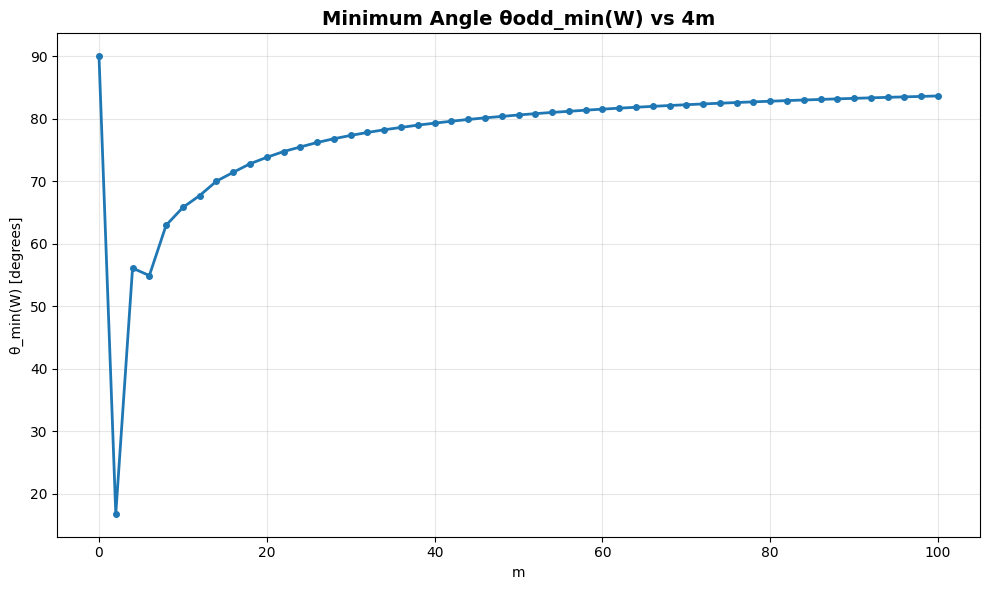


Minimum angles calculation completed!


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of m values to test
m_values = range(0, 101, 2)  # m from 0 to 100, step by 2
theta_min_vals = []  # Store minimum angles

for m in m_values:
    print("=" * 60)
    print(f"Testing for m = {m}")
    print("=" * 60)

    try:
        p = 0
        N = 4 * m + 2
        theta = 2 * p

        # Check if theta is in the valid range [0, N)
        if not (0 <= theta < N):
            print(f"Error: theta = {theta} is not in the valid range [0, {N})")
            continue

        # Calculate w and G_theta
        w = np.exp((-2 * np.pi * 1j) / N)
        G_theta = np.zeros((N, N), dtype=complex)
        for k in range(N):
            for l in range(N):
                exponent = (k - theta/2) * (l - theta/2)
                G_theta[k, l] = (1/np.sqrt(N)) * (w ** exponent)

        # Identity matrix
        I = np.eye(N)

        # Calculate G_theta squared
        G_squared = np.dot(G_theta, G_theta)

        # Calculate P_theta and Q_theta
        P_theta = 0.5 * (I - G_squared)
        Q_theta = 0.5 * (I + G_squared)

        # Extract real parts
        P_theta_real = np.real(P_theta)
        Q_theta_real = np.real(Q_theta)

        # Calculate S and C
        S = np.imag(G_theta)
        C = np.real(G_theta)

        # Construct Phi matrix with safe indexing
        components = []

        if p + 1 > 0:
            q_first = Q_theta_real[:p+1, :]
            components.append(q_first)

        if 2*m + 1 - p > 0:
            q_last = Q_theta_real[-(2*m+1-p):, :]
            components.append(q_last)

        if p > 0:
            p_first = P_theta_real[:p, :]
            components.append(p_first)

        if 2*m - p > 0:
            p_last = P_theta_real[-(2*m-p):, :]
            components.append(p_last)

        # Combine all rows to form Phi
        if not components:
            print("Error: No rows selected for Phi matrix")
            continue

        Phi = np.vstack(components)

        # Use pseudo-inverse instead of regular inverse for stability
        Phi_inv = np.linalg.pinv(Phi)

        # Calculate the transformation: Phi @ S @ Phi_inv
        result = Phi @ S @ Phi_inv

        # Extract the B block
        if result.shape[0] < 2*m+2:
            print(f"Cannot extract block of size {2*m+2}x{2*m+2}")
            continue

        B = result[2*m+2:, 2*m+2:]

        # Create Vp and Vm matrices
        B_size = B.shape[0]
        I_B = np.eye(B_size)
        Vp = np.zeros((N, N))
        Vm = np.zeros((N, N))
        Vp[N-B_size:, :B_size] = B + I_B
        Vm[N-B_size:, :B_size] = B - I_B

        # Combine first two columns of Vp and first two columns of Vm
        M = np.hstack((Vp[:, :m], Vm[:, :m]))

        # Construct second Phi matrix
        components2 = []

        if p + 1 > 0:
            q_first = Q_theta_real[:p+1, :]
            components2.append(q_first)

        if 2*m +1- p > 0:
            q_last = Q_theta_real[-(2*m+1-p):, :]
            components2.append(q_last)

        if p > 0:
            p_first = P_theta_real[:p, :]
            components2.append(p_first)

        if 2*m - p > 0:
            p_last = P_theta_real[-(2*m-p):, :]
            components2.append(p_last)

        if not components2:
            print("Error: No rows selected for Phi2 matrix")
            continue

        Phi2 = np.vstack(components2)
        Phi2_inv = np.linalg.inv(Phi2)

        # Calculate the transformation: Phi2 @ C @ Phi2_inv
        result2 = Phi2 @ C @ Phi2_inv

        if result2.shape[0] < 2*m+2:
            print(f"Cannot extract block of size {m+1}x{m+1}")
            continue

        A = result2[0:2*m+2, 0:2*m+2]

        # Create Vp1 and Vm1 matrices
        A_size = A.shape[0]
        I_A = np.eye(A_size)
        Vp1 = np.zeros((N, N))
        Vm1 = np.zeros((N, N))
        Vp1[:A_size, :A_size] = A + I_A
        Vm1[:A_size, :A_size] = A - I_A

        # Combine first three columns of Vp1 and first three columns of Vm1
        N_matrix = np.hstack((Vp1[:, :m+1], Vm1[:, :m+1]))

        # Combine columns of M and N matrices side by side
        V = np.hstack((M, N_matrix))

        # Calculate W = Phi⁻¹ @ V
        W = np.linalg.inv(Phi) @ V

        # === Calculate Minimum Angle (Third plot) ===
        def normalize_column(col):
            return col / np.linalg.norm(col)

        def normalize_columns(matrix):
            return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

        Wn = normalize_columns(W)
        min_angle = np.pi

        for i in range(Wn.shape[1]):
            for j in range(i + 1, Wn.shape[1]):
                inner = np.clip(np.dot(Wn[:, i], Wn[:, j]), -1.0, 1.0)
                angle = np.arccos(inner)
                if angle < min_angle:
                    min_angle = angle

        theta_min_vals.append(np.degrees(min_angle))
        print(f"Minimum angle for m = {m}: {np.degrees(min_angle):.6f} degrees")

    except Exception as e:
        print(f"Error occurred for m = {m}: {str(e)}")
        theta_min_vals.append(np.nan)  # Add NaN for failed cases
        continue

# === Plot Minimum Angle ===
plt.figure(figsize=(10, 6))
plt.plot(m_values, theta_min_vals, marker='o', markersize=4, linewidth=2)
plt.title("Minimum Angle θodd_min(W) vs 4m", fontsize=14, fontweight='bold')
plt.xlabel("m")
plt.ylabel("θ_min(W) [degrees]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMinimum angles calculation completed!")